In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", default_assay="RNA", nthreads=4)
ds

DataStore has 7399 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA+ADT_wnn_UMAP1', 'RNA+ADT_UMAP1', 
            'RNA_percentRibo', 'RNA_percentMito', 'RNA_clusters', 'ADT_UMAP2', 'ADT_nFeatures', 
            'ADT_UMAP1', 'RNA+ADT_wnn_UMAP2', 'ADT_nCounts', 'RNA+ADT_leiden_cluster', 'RNA_UMAP2', 
            'RNA+ADT_UMAP2', 'ADT_leiden_cluster', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 
            'RNA_UMAP1', 'RNA+ADT_wnn_leiden_cluster'
   ADT assay has 17 features and following metadata:
            'I', 'ids', 'names', 'read', 'pattern', 
            'sequence', 'nCells', 'feature_type', 'dropOuts', 'genome', 
          
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'genome', 'pattern', 
            'nCells', 'sequence', 'dropOuts', 'read', 'feature_type', 
          

In [2]:
rna_run = ds.pipeline.open(label="docs_default")
cell_selection = rna_run["analysis_cell_selection"]
rna_initialization = rna_run["embedding_initialization"]
rna_neighbors = rna_run["neighbors"]
rna_graph = rna_run["connectivity_map"]
rna_umap = rna_run["umap"]
rna_clusters = rna_run["leiden_1.0"]

cell_mask = rna_run.cells.fetch_all("I")
print(f"Selected cells: {int(cell_mask.sum())} of {len(cell_mask)}")

Selected cells: 7399 of 7865


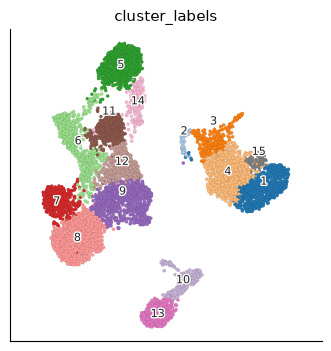

In [3]:
ds.plots.embedding(layout=rna_umap, color_by=rna_clusters)

In [4]:
adt_names = ds.ADT.feats.fetch_all("names").astype(str)
adt_panel = pd.DataFrame({"name": adt_names})
adt_panel["is_control"] = adt_panel["name"].str.lower().str.contains("control")
adt_panel[adt_panel["is_control"]]

,name,is_control
14,IgG2a_control_TotalSeqB,True
15,IgG1_control_TotalSeqB,True
16,IgG2b_control_TotalSeqB,True


In [5]:
adt_features = ds.set_feature_selection(
    from_assay="ADT",
    mask=~adt_panel["is_control"].to_numpy(),
)
adt_feature_values = np.asarray(ds.load_artifact(adt_features)["values"][:])
print(f"Selected ADT features: {int(adt_feature_values.sum())} of {len(adt_panel)}")

normalized_adt = ds.run_normalization(cell_selection, adt_features)
n_adt_features = int(ds.load_artifact(normalized_adt)["data"].shape[1])
adt_reduction = ds.run_custom_reduction(
    np.eye(n_adt_features, dtype=np.float64),
    normalized_adt,
)
adt_initialization = ds.build_embedding_initialization(adt_reduction)
adt_ann = ds.build_ann_index(adt_reduction)
adt_neighbors = ds.query_neighbors(adt_ann, k=21)
adt_graph = ds.build_connectivity_map(adt_neighbors)
adt_umap = ds.run_umap(adt_graph, adt_initialization)
adt_clusters = ds.run_leiden_clustering(adt_graph, resolution=1)

Selected ADT features: 14 of 17


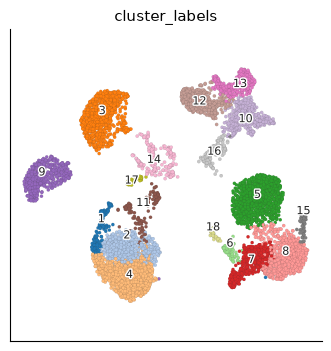

In [6]:
ds.plots.embedding(layout=adt_umap, color_by=adt_clusters)

In [7]:
snn_graph = ds.integrate_assays([rna_graph, adt_graph], method="snn")
snn_umap = ds.run_umap(snn_graph, rna_initialization)
snn_clusters = ds.run_leiden_clustering(snn_graph, resolution=1.75)

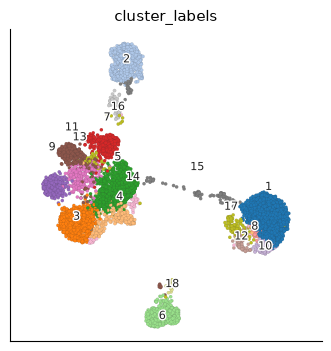

In [8]:
ds.plots.embedding(layout=snn_umap, color_by=snn_clusters)

In [9]:
wnn_graph = ds.integrate_assays(
    [rna_neighbors, adt_neighbors],
    method="wnn",
    l2_normalize=True,
)
wnn_umap = ds.run_umap(wnn_graph, rna_initialization)
weight_values = np.asarray(ds.load_artifact(wnn_graph)["modality_weights"][:])

pd.Series(
    {
        "minimum weight": float(weight_values.min()),
        "maximum weight": float(weight_values.max()),
        "mean RNA weight": float(weight_values[:, 0].mean()),
        "mean ADT weight": float(weight_values[:, 1].mean()),
        "maximum row-sum error": float(np.abs(weight_values.sum(axis=1) - 1).max()),
    }
)

minimum weight           0.000000
maximum weight           1.000000
mean RNA weight          0.511584
mean ADT weight          0.488416
maximum row-sum error    0.000000
dtype: float64

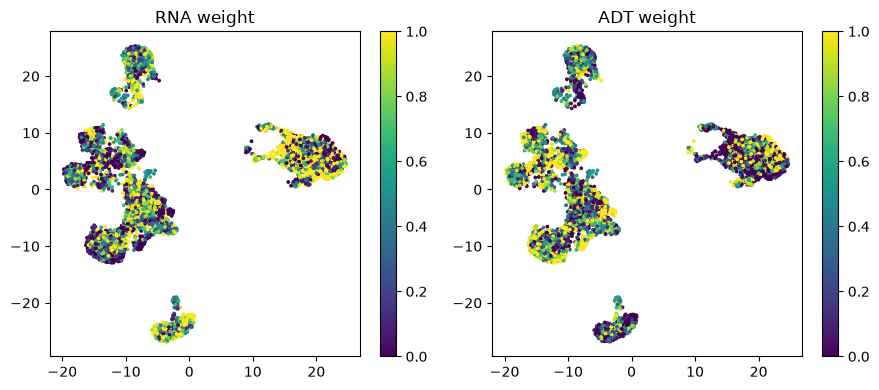

In [10]:
wnn_umap_values = np.asarray(ds.load_artifact(wnn_umap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, index, title in (
    (axes[0], 0, "RNA weight"),
    (axes[1], 1, "ADT weight"),
):
    points = axis.scatter(
        wnn_umap_values[:, 0],
        wnn_umap_values[:, 1],
        c=weight_values[:, index],
        s=3,
    )
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure